<a href="https://colab.research.google.com/github/felrojas1/MiPrimeraAplicacionS31/blob/master/propuesta_hacienda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Auditoría de Datos: Impacto Social de las Recomendaciones Presupuestarias


🧠 Minería de Datos aplicada al Control de Políticas Públicas


✍️ Autor del análisis: Felipe Rojas Villacura


📅 Fecha: Abril 2026


🔍 Objetivo: Auditar, mediante estadística descriptiva y análisis exploratorio de datos (EDA), la lista de programas sociales recomendados para descontinuación por el Ministerio de Hacienda, evaluando la validez del criterio de "eficiencia" y midiendo el impacto real en la entrega de beneficios sociales.



📌 Disclaimer
Este análisis utiliza datos oficiales del Ministerio de Desarrollo Social y Familia (MIDESO) y las minutas de recomendación del Ministerio de Hacienda. Como analista, me comprometo a dejar que los datos hablen por sí mismos. El objetivo de este documento es elevar el nivel del debate político, pasando de las consignas a la evidencia matemática irrefutable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.2f}'.format

Para este estudio, cruzamos el gasto real ejecutado de los programas (dataset MIDESO) con la sentencia política de mantenerlos o cerrarlos (dataset Hacienda).

In [3]:
# Carga de datos
df_ejecutado = pd.read_excel('/content/sample_data/datos_mh.xlsx', sheet_name='MIDESO_gasto_ejecutado_BIPS_202')
df_recoms = pd.read_excel('/content/sample_data/datos_mh.xlsx', sheet_name='recoms_MH')

# Limpieza de columnas innecesarias en las recomendaciones para evitar duplicados.
df_recoms_limpio = df_recoms[['id_bips', 'Indicación hacienda']]


In [4]:
# Inner Join para estudiar solo los programas evaluados
df_estudio = pd.merge(
    df_recoms_limpio,
    df_ejecutado,
    left_on='id_bips',
    right_on='ID_programa',
    how='inner'
)

In [5]:
# Tratamos los valores nulos, importante para sumar gastos regionales sin errores
cols_financieras = [
    'Gastos_componentes_d', 'Gastos_admin_e', 'Total_ejecutado_d_e',
    'Gastos_gores_c', 'Gasto total ejecutado 2024 (M$2025)'
]
df_estudio[cols_financieras] = df_estudio[cols_financieras].fillna(0)

print(f"Dataset integrado con éxito. Total de programas a analizar: {len(df_estudio)}")

Dataset integrado con éxito. Total de programas a analizar: 649


# 🧮 Creación de KPIs con la Ingenieria de Caracteristicas


Para rebatir el argumento de la "Grasa Estatal", no podemos mirar solo los montos brutos. Necesitamos entender qué porcentaje del dinero llega realmente a la gente.


Definimos el **Ratio de Beneficio:** de cada $100 gastados, cuántos van al componente social vs. la administración.

In [6]:
# Etiquetado de la variable objetivo
df_estudio['Estado_Hacienda'] = np.where(
    df_estudio['Indicación hacienda'].str.contains('Descontinuar', case=False, na=False),
    'Descontinuar',
    'Mantener'
)

In [7]:
# Cálculo de Eficiencia Social (Ratio de Beneficio)
df_estudio['Ratio_Beneficio'] = np.where(
    df_estudio['Total_ejecutado_d_e'] > 0,
    df_estudio['Gastos_componentes_d'] / df_estudio['Total_ejecutado_d_e'],
    0
)

In [8]:
#Cálculo de Ineficiencia (Ratio Administrativo)
df_estudio['Ratio_Admin'] = np.where(
    df_estudio['Total_ejecutado_d_e'] > 0,
    df_estudio['Gastos_admin_e'] / df_estudio['Total_ejecutado_d_e'],
    0
)

# 📉 Análisis Macro: "El Mito de la Eficiencia"


¿Está el Ministerio de Hacienda cortando los programas ineficientes? Comparemos los promedios macro.

In [9]:
resumen_macro = df_estudio.groupby('Estado_Hacienda').agg(
    Programas=('ID_programa', 'count'),
    Total_Recursos_M=('Gasto total ejecutado 2024 (M$2025)', 'sum'),
    Gasto_GORE_M=('Gastos_gores_c', 'sum'),
    Promedio_Ratio_Beneficio=('Ratio_Beneficio', 'mean')
).reset_index()

In [10]:
# Formato visual
resumen_macro['Total_Recursos_M'] = resumen_macro['Total_Recursos_M'].apply(lambda x: f"${x:,.0f}")
resumen_macro['Gasto_GORE_M'] = resumen_macro['Gasto_GORE_M'].apply(lambda x: f"${x:,.0f}")
resumen_macro['Promedio_Ratio_Beneficio'] = resumen_macro['Promedio_Ratio_Beneficio'].apply(lambda x: f"{x:.1%}")

display(resumen_macro)

,Estado_Hacienda,Programas,Total_Recursos_M,Gasto_GORE_M,Promedio_Ratio_Beneficio
0,Descontinuar,141,"$5,466,542,228","$5,116,399",87.2%
1,Mantener,508,"$32,337,640,852","$45,712,176",91.2%


Los datos revelan que los 141 programas sugeridos para eliminación operan con un **87.2% de eficiencia en entrega directa.** El gobierno no está cortando "grasa", está recortando más de $5.400 millones en ayuda social directa y asestando un golpe de **5.116** millones a las regiones (GORE).

# 📊  ¿Dónde golpea el corte?


Para entender la magnitud del daño, aislaremos los programas que Hacienda quiere cerrar y visualizaremos cómo se distribuye este recorte presupuestario.

In [12]:

df_recortes_graf = df_estudio[df_estudio['Estado_Hacienda'] == 'Descontinuar'].copy()
df_agrupado = df_recortes_graf.groupby('Servicio').agg(
    Presupuesto_Perdido=('Gasto total ejecutado 2024 (M$2025)', 'sum'),
    Ratio_Beneficio_Promedio=('Ratio_Beneficio', 'mean'),
    Cantidad_Programas=('ID_programa', 'count')
).reset_index()
df_agrupado['Eficiencia_Porcentual'] = df_agrupado['Ratio_Beneficio_Promedio'] * 100
df_agrupado = df_agrupado.sort_values(by='Presupuesto_Perdido', ascending=False)

# A. La Concentración del Recorte
Este gráfico demuestra que el recorte no es general, sino que castiga fuertemente a unos pocos ministerios clave.

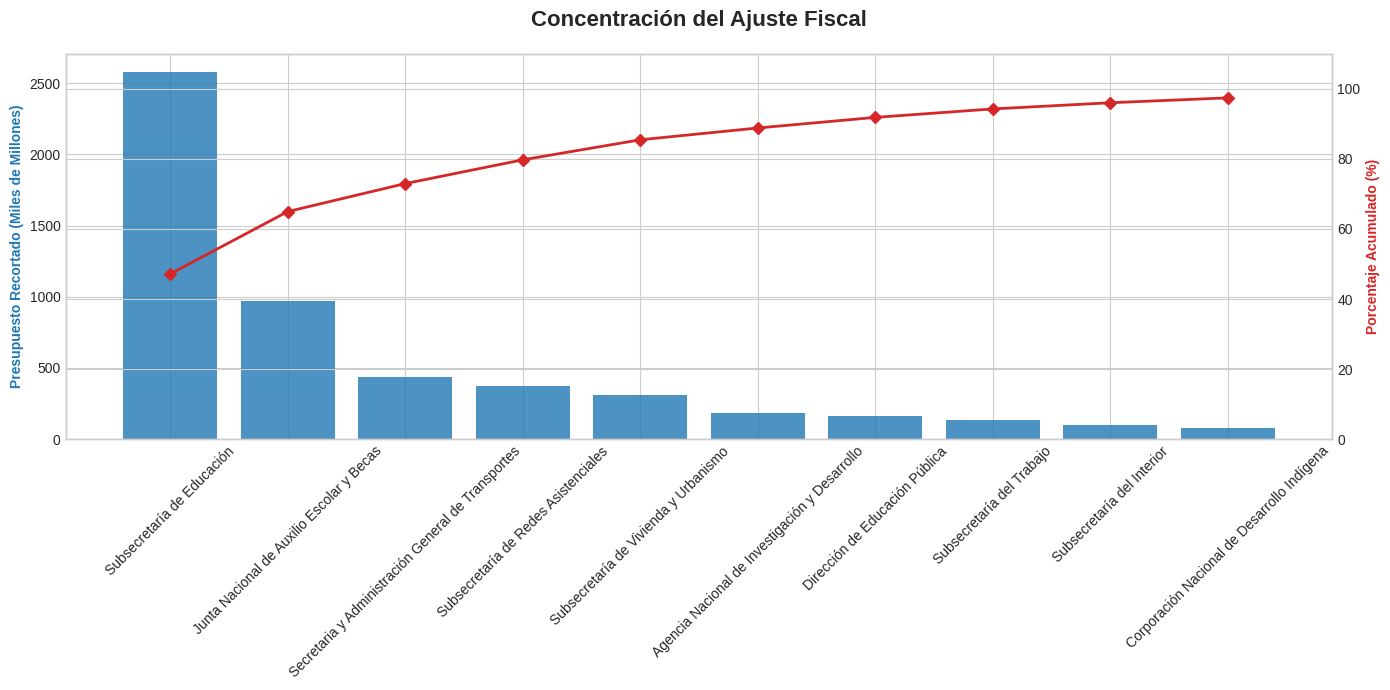

In [14]:
top_10 = df_agrupado.head(10).copy()
top_10['Porcentaje'] = top_10['Presupuesto_Perdido'] / df_agrupado['Presupuesto_Perdido'].sum() * 100
top_10['Acumulado'] = top_10['Porcentaje'].cumsum()

fig, ax1 = plt.subplots(figsize=(14, 7))
color_barra = '#1f77b4'
ax1.bar(top_10['Servicio'], top_10['Presupuesto_Perdido'] / 1e6, color=color_barra, alpha=0.8)
ax1.set_ylabel('Presupuesto Recortado (Miles de Millones)', color=color_barra, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
color_linea = '#d62728'
ax2.plot(top_10['Servicio'], top_10['Acumulado'], color=color_linea, marker='D', linewidth=2)
ax2.set_ylabel('Porcentaje Acumulado (%)', color=color_linea, fontweight='bold')
ax2.set_ylim(0, 110)

plt.title('Concentración del Ajuste Fiscal', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# B. Matriz de Impacto Social

# Sección nueva
Este gráfico de dispersión revela una inconsistencia técnica grave: se están eliminando programas de altísimo presupuesto que tienen una eficiencia superior al 95%.

In [17]:
fig2 = px.scatter(
    df_agrupado, x="Eficiencia_Porcentual", y="Presupuesto_Perdido",
    size="Cantidad_Programas", color="Servicio", hover_name="Servicio",
    log_y=True, size_max=45, template="plotly_white", height=600,
    title="El castigo a la Alta Eficiencia Social",
    labels={"Eficiencia_Porcentual": "Eficiencia de Entrega Directa (%)", "Presupuesto_Perdido": "Presupuesto (M$) [Log]"}
)
fig2.add_vline(x=90, line_dash="dash", line_color="red", annotation_text="Zona Crítica (>90%)")
fig2.update_xaxes(range=[60, 105])
fig2.show()

# C. Treemap del Daño Estructural
Tamaño = Dinero perdido. Intensidad del Rojo = Nivel de eficiencia destruida.

In [18]:
fig3 = px.treemap(
    df_agrupado[df_agrupado['Presupuesto_Perdido'] > 0],
    path=[px.Constant("Total Recortes Hacienda"), 'Servicio'],
    values='Presupuesto_Perdido', color='Eficiencia_Porcentual',
    color_continuous_scale='Reds', height=700,
    title='Mapa del Recorte Estructural'
)
fig3.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig3.show()

# Deteccion de anomalías: Mayor eficiencia sentenciada

En minería de datos, los outliers de alta eficiencia representan casos donde el algoritmo comete un error grosero de clasificación.


Filtramos aquellos programas con más de un 98% de eficiencia que el Ministerio propone cerrar.

In [19]:
# Identificamos
joyas_sociales = df_recortes_graf[df_recortes_graf['Ratio_Beneficio'] >= 0.98].sort_values(
    by='Gasto total ejecutado 2024 (M$2025)', ascending=False
).copy()

In [20]:
# Damos formato para el reporte
columnas_reporte = ['Servicio', 'Nombre', 'Ratio_Beneficio', 'Gasto total ejecutado 2024 (M$2025)']
tabla_joyas = joyas_sociales[columnas_reporte].copy()
tabla_joyas['Gasto total ejecutado 2024 (M$2025)'] = tabla_joyas['Gasto total ejecutado 2024 (M$2025)'].apply(lambda x: f"${x:,.0f}")
tabla_joyas['Ratio_Beneficio'] = tabla_joyas['Ratio_Beneficio'].apply(lambda x: f"{x:.1%}")

pd.set_option('display.max_colwidth', None)
display(tabla_joyas.head(10))
pd.reset_option('display.max_colwidth')

,Servicio,Nombre,Ratio_Beneficio,Gasto total ejecutado 2024 (M$2025)
46,Subsecretaría de Educación,Otras Subvenciones Escolares,99.9%,"$2,570,727,304"
1,Dirección de Educación Pública,Fondo de Apoyo a la Educación Pública,99.7%,"$165,409,192"
571,Subsecretaría del Trabajo,Inversión en la Comunidad,99.2%,"$130,133,328"
445,Corporación Nacional de Desarrollo Indígena,"Fondo de Tierras y Aguas Indígenas - Subsidio para la Adquisición de Tierras (Artículo 20, letras a y b)",98.3%,"$72,075,829"
187,Subsecretaría del Interior,Programa Contra el Crimen Organizado (PNCO),99.2%,"$70,995,506"
138,Subsecretaría de Redes Asistenciales,Fondo de Farmacia para Enfermedades Crónicas No Transmisibles en Atención Primaria (FOFAR),99.9%,"$51,746,236"
149,Subsecretaría de Redes Asistenciales,Programa Odontológico Integral,99.9%,"$36,183,724"
129,Subsecretaría de Redes Asistenciales,"Atención en salud integral para niños/as, adolescentes y jóvenes con vulneración de derechos y/o sujetos a la ley de responsabilidad penal adolescente.",99.5%,"$36,148,366"
141,Subsecretaría de Redes Asistenciales,Mejoramiento de Acceso a la Atención Odontológica,99.8%,"$30,085,083"
321,Agencia Nacional de Investigación y Desarrollo,Programa de Investigación Asociativa (PIA),99.0%,"$29,773,991"


# 🎯 Conclusión del Análisis


La evidencia extraída de los propios datos del gobierno desmiente el relato de la optimización del Estado:



**El Desmantelamiento de la Educación:** Se recortan más de $2.5 billones en "Otras Subvenciones Escolares" que operaban a un **99.9%** de eficiencia, sumado a los recortes directos en raciones de la JUNAEB **(96.3%).**

**Golpe a la Salud Pública:** Se cierra el Fondo de Farmacia para Enfermedades Crónicas **(99.9%)** y el Programa Odontológico Integral **(99.9%)**, afectando la supervivencia y calidad de vida de los pacientes de la red pública.

**Error en Seguridad:** En plena crisis delictual, el modelo recomienda el cierre del Programa Contra el Crimen Organizado, restándole más de $70 millones a la Subsecretaría del Interior en un programa que ejecutaba el **99.1%** de sus fondos de manera directa.